# 🏠 Indian House Price Prediction

## Objective

The goal of this project is to predict house prices using Machine Learning based on property features.

This notebook focuses on:

- Understanding the dataset
- Exploring the data
- Identifying data quality issues
- Generating business insights

In [2]:
import pandas as pd

import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("../data/raw/House_Price_Data.csv")

df.head()

,bhk,propertytype,location,sqft,pricepersqft,totalprice
0,3,Flat,Ahmedabad,1346,6233,15700000
1,4,Flat,Ahmedabad,1872,4873,17500000
2,4,Flat,Ahmedabad,1650,6733,20200000
3,5,Flat,Ahmedabad,10201,8499,86700000
4,3,Flat,Ahmedabad,968,5944,10400000


In [7]:
df.shape

(14119, 6)

The dataset contains 14119 rows and 6 columns.

In [8]:
df.columns

Index(['bhk', 'propertytype', 'location', 'sqft', 'pricepersqft',
       'totalprice'],
      dtype='str')

Features available:

- bhk
- propertytype
- location
- sqft
- pricepersqft
- totalprice

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14119 entries, 0 to 14118
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   bhk           14119 non-null  int64
 1   propertytype  14119 non-null  str  
 2   location      14119 non-null  str  
 3   sqft          14119 non-null  int64
 4   pricepersqft  14119 non-null  int64
 5   totalprice    14119 non-null  int64
dtypes: int64(4), str(2)
memory usage: 662.0 KB


In [11]:
df.describe()

,bhk,sqft,pricepersqft,totalprice
count,14119.000000,14119.000000,1.411900e+04,1.411900e+04
mean,2.709824,1562.767122,1.218960e+04,1.276700e+07
std,0.787175,8207.723233,2.599234e+05,2.111962e+07
min,1.000000,5.000000,2.100000e+01,1.100000e+05
25%,2.000000,916.000000,4.000000e+03,4.500000e+06
50%,3.000000,1210.000000,5.526000e+03,7.500000e+06
75%,3.000000,1620.000000,8.929000e+03,1.410000e+07
max,10.000000,799284.000000,2.000000e+07,8.686000e+08


In [13]:
df.isnull().sum()

bhk             0
propertytype    0
location        0
sqft            0
pricepersqft    0
totalprice      0
dtype: int64

There are no missing values in the dataset.

In [15]:
df.duplicated().sum()

np.int64(92)

Duplicate rows detected:

92

Duplicates will be removed during preprocessing.

In [16]:
df.dtypes

bhk             int64
propertytype      str
location          str
sqft            int64
pricepersqft    int64
totalprice      int64
dtype: object

# 📊 Visualization Section

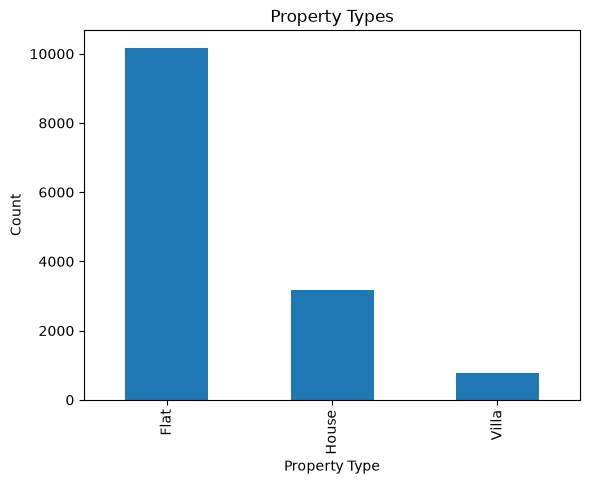

In [18]:
df["propertytype"].value_counts().plot(kind="bar")  #Property Type Distribution

plt.title("Property Types")

plt.xlabel("Property Type")

plt.ylabel("Count")

plt.show()

### flat are the most common property type.

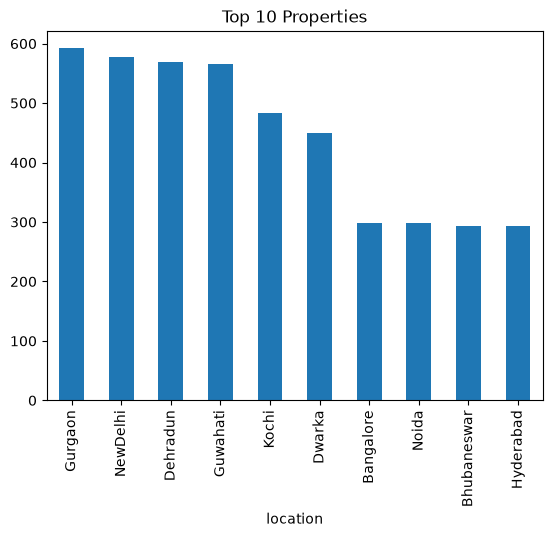

In [26]:
df["location"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Properties")

plt.show()

### gurugaon, newDelhi etc locations have significantly more listings than others.

<Axes: xlabel='bhk'>

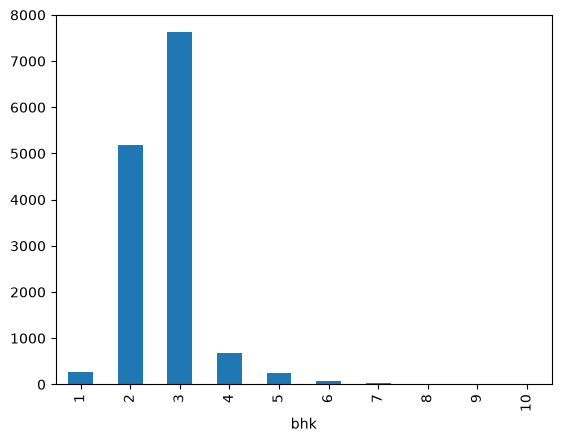

In [28]:
df["bhk"].value_counts().sort_index().plot(kind="bar")

### Most houses are 2–3 BHK.

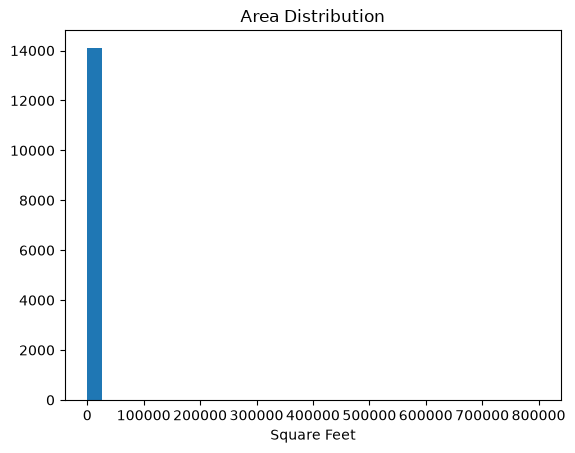

In [36]:
plt.hist(df["sqft"], bins = 30)

plt.title("Area Distribution")

plt.xlabel("Square Feet")

plt.show()

### Observation

The `sqft` feature is highly right-skewed due to a small number of extremely large property sizes. Most properties fall within a much smaller range, while a few outliers stretch the distribution significantly. These outliers will be investigated during preprocessing.

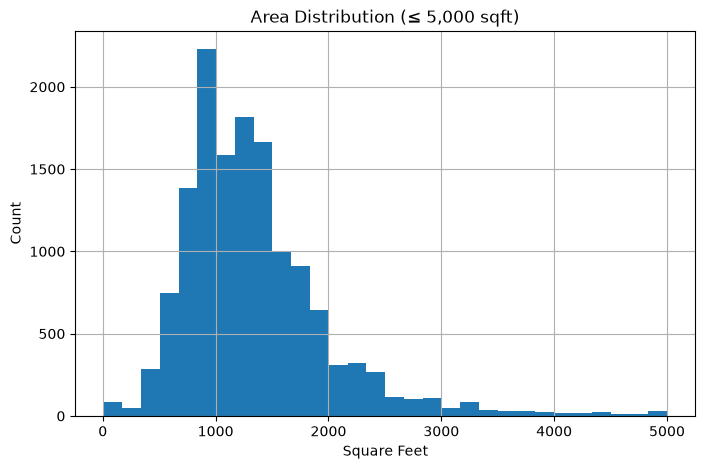

In [ ]:
plt.figure(figsize=(8,5))

df[df["sqft"] <= 5000]["sqft"].hist(bins=30)

plt.title("Area Distribution (≤ 5,000 sqft)")
plt.xlabel("Square Feet")
plt.ylabel("Count")

plt.show()

In [37]:
df["sqft"].describe()

count     14119.000000
mean       1562.767122
std        8207.723233
min           5.000000
25%         916.000000
50%        1210.000000
75%        1620.000000
max      799284.000000
Name: sqft, dtype: float64

In [38]:
df["sqft"].sort_values(ascending=False).head(10)

13522    799284
9068     302260
9069     302260
7582     200000
9798     152461
7235     145350
893      105035
11884    100000
11347     98134
10090     64000
Name: sqft, dtype: int64

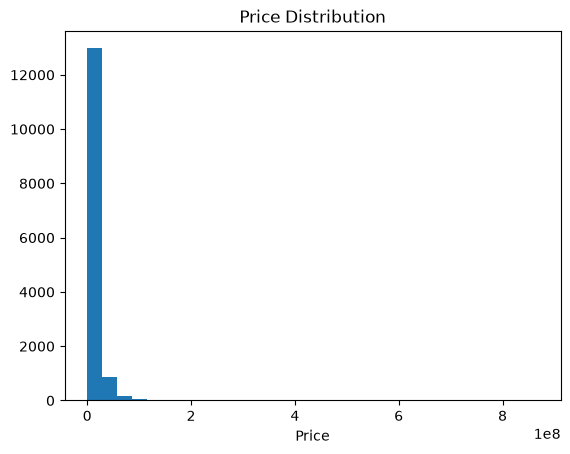

In [39]:
plt.hist(df["totalprice"], bins=30)

plt.title("Price Distribution")

plt.xlabel("Price")

plt.show()

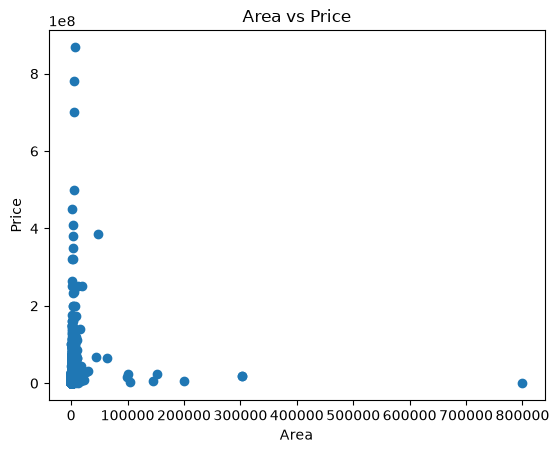

In [40]:
plt.scatter(df["sqft"], df["totalprice"])

plt.xlabel("Area")

plt.ylabel("Price")

plt.title("Area vs Price")

plt.show()

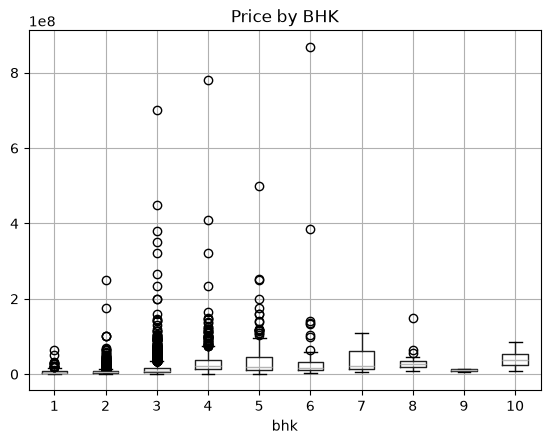

In [41]:
df.boxplot(column="totalprice", by="bhk")

plt.title("Price by BHK")

plt.suptitle("")

plt.show()

## Business Insights

- The dataset contains residential properties across multiple locations.
- Area appears to have a positive relationship with total price.
- Some locations have significantly more listings.
- The dataset contains duplicate records that require cleaning.
- Numerical and categorical features will require different preprocessing steps.

## Next Steps

- Remove duplicate records
- Encode categorical features
- Separate features and target
- Train Machine Learning models